In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/SASA_phosphorylated_residues/'

In [7]:
# all phosphorylated serine residues

proteins = ['ACYP1','FLNA21','FLNC24','FUS','GGCT','PARK7']
residues = [['pS71'],['pS2319'],['pS2718'],['pS340','pS346'],['pS136'],['chainA_pS47','chainB_pS47','chainA_pS57','chainB_pS57']]

nsims=3

avg = []
err = []
max_SASA = []
variant = []

for prot,RES in zip(proteins,residues):
    for res in RES:
        var = prot+str(' ')+res
    
        vals = []
        max_vals = []

        for s in range(1,nsims+1):

            dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(prot,res,s),skiprows=25)

            sasa = dat[:,2]
            time = dat[:,0]/1000 # convert to nanoseconds

            vals.append(np.mean(sasa)) 
            max_vals.append(np.max(sasa))

        avg.append(np.mean(vals))
        err.append(np.std(vals)/np.sqrt(nsims))
        variant.append(var)
        max_SASA.append(np.max(max_vals))
    
df = pd.DataFrame()
df['Variant'] = variant
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err
df['Max. SASA'] = max_SASA

df.to_csv('avg_SC_SASA_pSER.csv')
df

,Variant,SASA (nm$^{2}$),Error,Max. SASA
0,ACYP1 pS71,1.155485,0.092496,1.900
1,FLNA21 pS2319,1.480981,0.003392,1.877
2,FLNC24 pS2718,1.262958,0.000137,1.830
3,FUS pS340,0.318021,0.019363,1.267
4,FUS pS346,0.607591,0.053421,1.630
5,GGCT pS136,0.489929,0.100165,1.566
6,PARK7 chainA_pS47,0.710518,0.033050,1.854
7,PARK7 chainB_pS47,0.692486,0.092999,1.571
8,PARK7 chainA_pS57,0.616924,0.002150,1.352
9,PARK7 chainB_pS57,0.602106,0.001670,1.131


In [2]:
# all phosphorylated threonine residues

proteins = ['FUS','SRSF2']
residues = [['pT286'],['pT14','pT22','pT25']]

nsims=3

avg = []
err = []
max_SASA = []
variant = []

for prot,RES in zip(proteins,residues):
    for res in RES:
        var = prot+str(' ')+res
    
        vals = []
        max_vals = []

        for s in range(1,nsims+1):

            dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(prot,res,s),skiprows=25)

            sasa = dat[:,2]
            time = dat[:,0]/1000 # convert to nanoseconds

            vals.append(np.mean(sasa)) 
            max_vals.append(np.max(sasa))

        avg.append(np.mean(vals))
        err.append(np.std(vals)/np.sqrt(nsims))
        variant.append(var)
        max_SASA.append(np.max(max_vals))
    
df = pd.DataFrame()
df['Variant'] = variant
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err
df['Max. SASA'] = max_SASA

df.to_csv('avg_SC_SASA_pTHR.csv')
df

,Variant,SASA (nm$^{2}$),Error,Max. SASA
0,FUS pT286,0.339161,0.014831,1.382
1,SRSF2 pT14,0.183684,0.019935,1.500
2,SRSF2 pT22,0.363224,0.025780,1.606
3,SRSF2 pT25,1.139131,0.103916,2.176


In [9]:
# all phosphorylated threonine residues

proteins = ['PARK7']
residues = [['chainA_pY67']]

nsims=3

avg = []
err = []
max_SASA = []
variant = []

for prot,RES in zip(proteins,residues):
    for res in RES:
        var = prot+str(' ')+res
    
        vals = []
        max_vals = []

        for s in range(1,nsims+1):

            dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(prot,res,s),skiprows=25)

            sasa = dat[:,2]
            time = dat[:,0]/1000 # convert to nanoseconds

            vals.append(np.mean(sasa)) 
            max_vals.append(np.max(sasa))

        avg.append(np.mean(vals))
        err.append(np.std(vals)/np.sqrt(nsims))
        variant.append(var)
        max_SASA.append(np.max(max_vals))
    
df = pd.DataFrame()
df['Variant'] = variant
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err
df['Max. SASA'] = max_SASA

df.to_csv('avg_SC_SASA_pTYR.csv')
df

,Variant,SASA (nm$^{2}$),Error,Max. SASA
0,PARK7 chainA_pY67,1.256089,0.064545,2.893


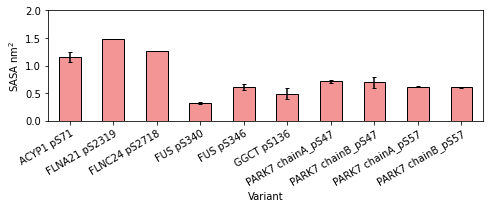

In [29]:
# plot
df = pd.read_csv('avg_SC_SASA_pSER.csv')
df.plot(x='Variant',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (7,3),legend=False,color = '#F49595',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=30,rotation_mode='anchor',ha='right')
plt.ylim(0,2)

plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('pSER_SASA_barplot.pdf')

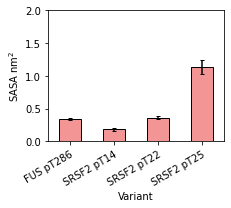

In [5]:
# plot
df = pd.read_csv('avg_SC_SASA_pTHR.csv')
df.plot(x='Variant',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (3.4,3),legend=False,color = '#F49595',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=30,rotation_mode='anchor',ha='right')
plt.ylim(0,2)

plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('pTHR_SASA_barplot.pdf')

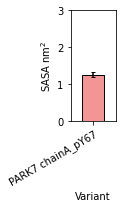

In [31]:
# plot
df = pd.read_csv('avg_SC_SASA_pTYR.csv')
df.plot(x='Variant',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (1.53,3),legend=False,color = '#F49595',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=30,rotation_mode='anchor',ha='right')
plt.ylim(0,3)

plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('pTYR_SASA_barplot.pdf')

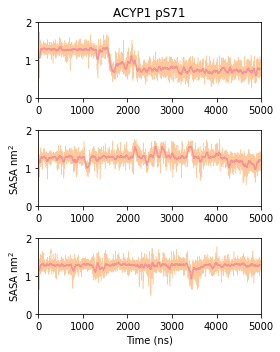

In [44]:
# individual simulation plots of the buried PTMs

protein = 'ACYP1'
res = 'pS71'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,5000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

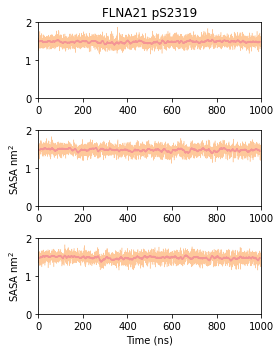

In [45]:
# individual simulation plots of the buried PTMs

protein = 'FLNA21'
res = 'pS2319'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,1000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

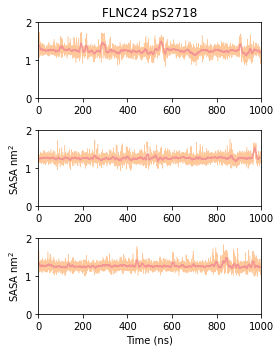

In [46]:
# individual simulation plots of the buried PTMs

protein = 'FLNC24'
res = 'pS2718'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,1000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

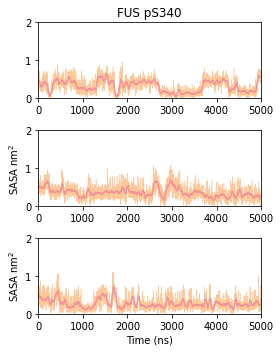

In [47]:
# individual simulation plots of the buried PTMs

protein = 'FUS'
res = 'pS340'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,5000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

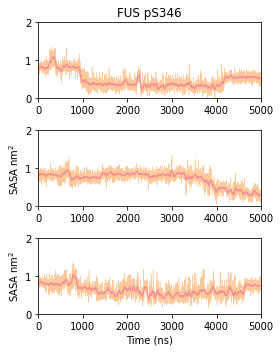

In [53]:
# individual simulation plots of the buried PTMs

protein = 'FUS'
res = 'pS346'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,5000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

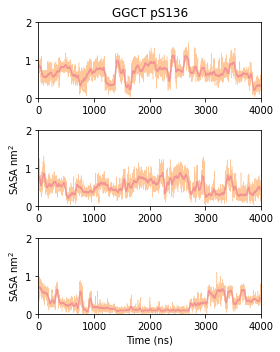

In [55]:
# individual simulation plots of the buried PTMs

protein = 'GGCT'
res = 'pS136'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,4000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

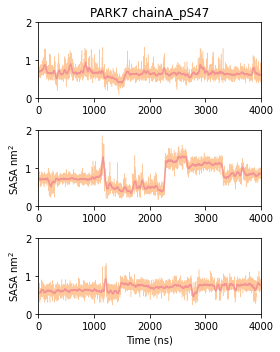

In [56]:
# individual simulation plots of the buried PTMs

protein = 'PARK7'
res = 'chainA_pS47'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,4000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

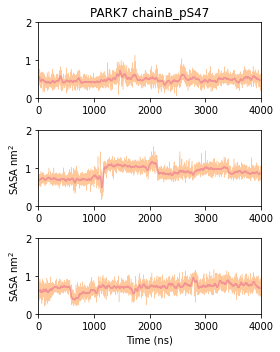

In [57]:
# individual simulation plots of the buried PTMs

protein = 'PARK7'
res = 'chainB_pS47'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,4000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

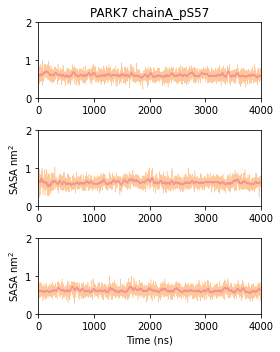

In [58]:
# individual simulation plots of the buried PTMs

protein = 'PARK7'
res = 'chainA_pS57'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,4000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

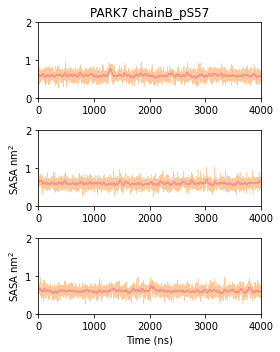

In [59]:
# individual simulation plots of the buried PTMs

protein = 'PARK7'
res = 'chainB_pS57'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,4000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

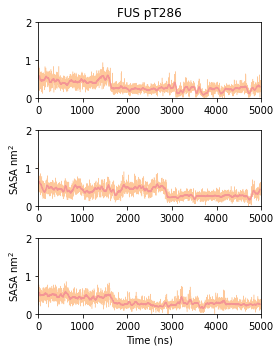

In [6]:
# individual simulation plots of the buried PTMs

protein = 'FUS'
res = 'pT286'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,5000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

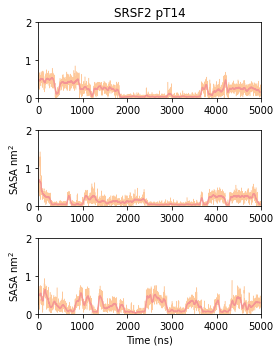

In [50]:
# individual simulation plots of the buried PTMs

protein = 'SRSF2'
res = 'pT14'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,5000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

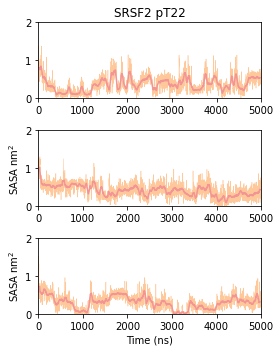

In [60]:
# individual simulation plots of the buried PTMs

protein = 'SRSF2'
res = 'pT22'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,5000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

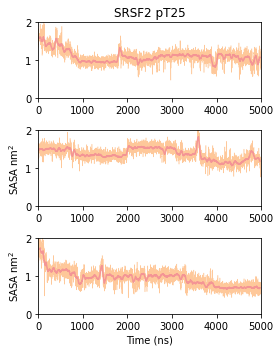

In [51]:
# individual simulation plots of the buried PTMs

protein = 'SRSF2'
res = 'pT25'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,2)
    plt.xlim(0,5000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))

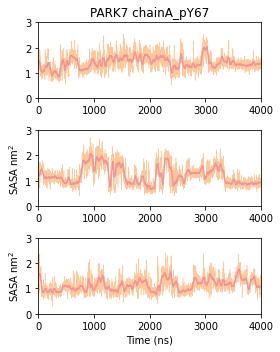

In [52]:
# individual simulation plots of the buried PTMs

protein = 'PARK7'
res = 'chainA_pY67'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    
    dat = np.loadtxt(path+"{}/sasa_{}_{}.xvg".format(protein,res,s),skiprows=25)
    if len(dat)>2e5:
        dat = dat[::50] # downsample 10k, 1 ns frequency
    else:
        dat = dat[::10] # downsample 10k, 1 ns  frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,3)
    plt.xlim(0,4000)

    if s==1:
        plt.title(protein+str(' ')+res)
    elif s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}_{}.pdf'.format(protein,res))